In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:
include("model/sde.jl")
sde(randn(64,64),1)

64×64 Matrix{Float32}:
  1.09404   -1.26817     1.06603   …  -1.01825   -0.150802    0.852821
 -0.82618    2.26434     0.180847     -0.7645     1.3106     -0.16913
  3.03353    0.0489643   0.953605     -0.257902  -2.24041    -0.662875
 -0.280108   1.03694    -0.190045      1.11604    0.0258251  -0.778624
 -1.06909   -0.0140271   2.92011       0.951778   1.28536     0.269287
  0.719757  -0.638714   -0.505203  …   0.791777   1.51919     0.576753
 -1.25453   -1.37811    -0.142088     -0.721435   1.49002     0.386038
 -0.823072   0.0197575   0.134026      0.413398   0.437851   -0.22751
 -0.668322  -1.56865    -0.26676      -1.66405    0.260197   -0.930691
 -0.357942  -0.690219    1.37615       0.297712  -0.330663   -0.0278316
  ⋮                                ⋱                         
 -0.235327   0.318455   -1.18213   …  -1.82484   -0.0723308  -2.67567
  1.28237    0.740489    0.66091       0.885307   0.920337   -0.110042
  1.91349   -1.61929     0.9623       -0.216937  -1.64718    -1.1

Now we need to differentiate the model:

In [3]:
η = 0.15

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g

0.0

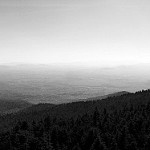

In [4]:
img = load("1096.jpg")

In [5]:
itp = interpolate_array_2D(Float64.(img))

#interpolate_array_2D##0 (generic function with 1 method)

In [6]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.662071948030728
 0.6844350473112837
 0.6927977157805238
 0.6702852217531009
 0.6757136120745573
 0.6894434399964395
 0.68419175360409
 0.6672001101490135
 0.6806489158672026
 0.6971524452344504
 ⋮
 0.031167250350174577
 0.015510000235997853
 0.014520427059962128
 0.007829287198868289
 0.00883805925916716
 0.008600073232173745
 0.014341377282337255
 0.012685658965159618
 0.019464199801231867

In [7]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [8]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  1.094054 seconds (671.57 k allocations: 853.562 MiB, 33.36% gc time, 20.15% compilation time)


In [25]:
img_start = load("Tikhonov/1.000e-01_0.000e+00_0.000e+00_0.000e+00.png")
itp_start = interpolate_array_2D(Float64.(img_start))
σ_vec = project_function_to_fem(fe, itp_start)
σ_vec .= min.(max.(σ_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.5764705882352937
 0.5764705882352942
 0.576470588235294
 0.5764705882352937
 0.5764705882352942
 0.5764705882352945
 0.5764705882352942
 0.5764705882352946
 0.5764705882352936
 0.5803921568627453
 ⋮
 0.04215686274509804
 0.04313725490196076
 0.0431372549019608
 0.043137254901960756
 0.042156862745098056
 0.0470588235294118
 0.04705882352941183
 0.04509803921568626
 0.04509803921568627

In [26]:
using Distributions
#σ_vec = rand(Uniform(1e-6, 1.0), fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_dict, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [27]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [28]:
f,∂f = create_f∂f(prblm, 255; gn=true)

(ModularEIT.var"#57#58"{String, typeof(objective_neumann_init!), Bool, FerriteProblem, Int64, Base.RefValue{Bool}}("neumann", ModularEIT.objective_neumann_init!, true, FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-

In [29]:
function grad_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    ∂f(σ64) 
    img64 = reshape(evaluate_at_points(ph, prblm.fe.dh, ∂f(σ64)),(64,64))
    Float32.(normalize_image(img64))
end
function obj_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    f(σ64)
end

obj_A (generic function with 1 method)

In [30]:
σ₁ = reshape(evaluate_at_points(ph, prblm.fe.dh, σ_vec),(64,64))
σ₁ = Float32.(normalize_image(σ₁))

64×64 Matrix{Float32}:
  0.152941   0.152941   0.160784  …   0.160784   0.152941   0.160784
  0.152941   0.152941   0.160784      0.168628   0.160784   0.168628
  0.160784   0.160784   0.160784      0.168628   0.168628   0.176471
  0.176471   0.176471   0.176471      0.168628   0.168628   0.168628
  0.2        0.2        0.192157      0.160784   0.160784   0.160784
  0.231373   0.223529   0.215686  …   0.152941   0.145098   0.145098
  0.254902   0.247059   0.239216      0.137255   0.137255   0.129412
  0.278431   0.262745   0.254902      0.129412   0.121569   0.113726
  0.286275   0.278431   0.270588      0.121569   0.113726   0.0980393
  0.294118   0.286275   0.278431      0.113726   0.105882   0.105882
  ⋮                               ⋱                        
 -0.623529  -0.631373  -0.639216  …  -0.858824  -0.85098   -0.866667
 -0.670588  -0.670588  -0.686275     -0.866667  -0.858824  -0.87451
 -0.733333  -0.72549   -0.733333     -0.87451   -0.866667  -0.858824
 -0.788235  -0.78039

In [84]:
using LinearAlgebra

function sample_step!(μ, model, A, ∂A, λ, τ)
    # sample t ∈ [0, T]
    t = rand(Uniform(0, T))
    αbar = ᾱ(t)

    # sample noise
    ε = randn(size(μ))

    # forward evaluate
    xt = sqrt(αbar) .* μ .+ sqrt(1 - αbar) .* ε
    ϵ_pred = model(xt, t)

    # λ_t = λ / SNR_t = λ * σ_t / α_t
    αt = sqrt(αbar)
    σt = sqrt(1 - αbar)
    λ_t = λ * σt / αt

    obj_A    = A(μ)
    obj_diff = dot(ϵ_pred .- ε, μ)
    obj = obj_A + λ_t * obj_diff

    grad_A    = ∂A(μ)
    grad_diff = ϵ_pred .- ε 
    grad = grad_A .+ λ_t .* grad_diff

    μ_new = μ .- τ .* grad
    return μ_new, t, obj, obj_A, obj_diff
end

sample_step! (generic function with 1 method)

In [85]:
using Printf
fmt(x) = @sprintf("%.3e", x)

fmt (generic function with 1 method)

In [ ]:
σᵢ, _ = sample_step!(σ₁, sde, obj_A, grad_A, 1e-4, 1e-3)

([0.16294079076249066 0.16294072289625883 … 0.16294083448962743 0.17078411532314403; 0.16294105181238686 0.1629408928396103 … 0.17078400924797102 0.17862687318373272; … ; -0.8880382935651245 -0.8880388989892604 … -0.9037256924462919 -0.9037254678868355; -0.8958819359169459 -0.8958818665400361 … -0.8958826086104786 -0.8958819990912611], 0.5199955864033947, 0.03584753500308413, 0.029318890886637982, 17.13046068381553)

In [ ]:
for i in 1:20
    σᵢ, tᵢ, objᵢ, obj_Aᵢ, obj_diffᵢ = sample_step!(σᵢ, sde, obj_A, grad_A, 0.0, 1e-5)
    println("$i $(fmt(tᵢ)) $(fmt(obj_Aᵢ)) $(fmt(obj_diffᵢ)) ")
end

1 4.166e-01 3.442e-02 4.995e+01 
2 9.125e-01 3.504e-02 1.130e+01 
3 5.947e-01 3.566e-02 7.705e+01 
4 7.828e-01 3.627e-02 2.722e+01 
5 2.045e-01 3.688e-02 4.374e+00 
6 2.865e-01 3.747e-02 2.599e+01 
7 5.029e-01 3.806e-02 4.049e+01 
8 6.203e-01 3.865e-02 6.948e+01 
9 5.392e-01 3.922e-02 6.419e+01 
10 5.025e-01 3.978e-02 5.533e+01 
11 5.026e-01 4.034e-02 5.847e+01 
12 8.619e-01 4.089e-02 1.515e+01 
13 5.816e-01 4.143e-02 7.179e+01 
14 2.483e-01 4.197e-02 1.852e+01 
15 9.636e-01 4.249e-02 7.613e+00 
16 4.211e-01 4.301e-02 2.978e+01 
17 3.329e-01 4.352e-02 3.355e+01 
18 8.030e-01 4.402e-02 2.480e+01 
19 8.930e-01 4.452e-02 1.296e+01 
20 7.097e-01 4.501e-02 3.383e+01 


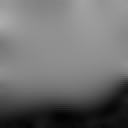

In [88]:
solution = Gray.(clamp.(denormalize_image(σᵢ),0.0,1.0))

In [89]:
fname = "RED_Diff/$(fmt(σf))_$(fmt(σg))_$(fmt(η)).png"


"RED_Diff/0.000e+00_0.000e+00_1.500e-01.png"